# Machine Learning pour prédire intéraction nouvelle productrice

## Exploration des données

In [1]:
import pandas as pd

data = pd.read_csv("../data/sortie/dataset_complet_sans_auto_inhibition.csv")

# Suppression des lignes contenant au moins un NaN
df = data.dropna()

print(f"Lignes avant nettoyage : {len(data)}")
print(f"Lignes après nettoyage : {len(df)}")
print(f"Lignes supprimées : {len(data) - len(df)}")


Lignes avant nettoyage : 1259
Lignes après nettoyage : 964
Lignes supprimées : 295


In [2]:

# Suppression des colonnes inutiles
df = df.drop(columns=["Souche_P", "Souche_C"], errors="ignore")

# Suppression des colonnes contenant des gènes "hypothetical"
df = df[[c for c in df.columns if "hypothetical" not in c.lower()]]

# Exploration des variables et observations
nb_obs, nb_total = df.shape

binaires = [c for c in df.columns if set(df[c].dropna().unique()) <= {0, 1}]
nb_binaires = len(binaires)
nb_non_binaires = nb_total - nb_binaires

print(f"Nombre d'observations : {nb_obs}")
print(f"Nombre de variables   : {nb_total}")
print(f"Nombre de variables binaires : {nb_binaires}")
print(f"Nombre de variables non binaires : {nb_non_binaires}")

Nombre d'observations : 964
Nombre de variables   : 9588
Nombre de variables binaires : 741
Nombre de variables non binaires : 8847


In [3]:
# Vérification de la variabilité des gènes
variabilite = df[binaires].nunique()
genes_constants = variabilite[variabilite == 1].index.tolist()
genes_variables = variabilite[variabilite > 1].index.tolist()

print(f"Nombre de gènes constants (pas de variabilité) : {len(genes_constants)}")
print(f"Nombre de gènes variables : {len(genes_variables)}")

Nombre de gènes constants (pas de variabilité) : 226
Nombre de gènes variables : 515


In [4]:
# Supposons que ta liste de gènes constants s'appelle genes_constants
genes_constants_P = [g for g in genes_constants if g.endswith('_P')]
genes_constants_C = [g for g in genes_constants if g.endswith('_C')]

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - dont gènes productrices (_P) : {len(genes_constants_P)}")
print(f" - dont gènes cibles (_C)       : {len(genes_constants_C)}")

# Optionnel : vérification que tout est compté
reste = len(genes_constants) - (len(genes_constants_P) + len(genes_constants_C))
if reste > 0:
    print(f" {reste} gènes constants n'ont ni suffixe _P ni _C.")

Nombre total de gènes constants : 226
 - dont gènes productrices (_P) : 113
 - dont gènes cibles (_C)       : 113


In [5]:
# Vérifie la valeur unique (0 ou 1) pour chaque gène constant
valeurs_constants = {g: df[g].unique()[0] for g in genes_constants}

# Comptage des gènes constants à 0 et à 1
nb_constants_0 = sum(v == 0 for v in valeurs_constants.values())
nb_constants_1 = sum(v == 1 for v in valeurs_constants.values())

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - constants à 0 : {nb_constants_0}")
print(f" - constants à 1 : {nb_constants_1}")

Nombre total de gènes constants : 226
 - constants à 0 : 226
 - constants à 1 : 0


In [6]:
# Suppression des gènes constants
df = df.drop(columns=genes_constants)

In [7]:
nb_obs, nb_total = df.shape

# Colonnes binaires (gènes)
binaires = [c for c in df.columns if set(df[c].dropna().unique()) <= {0, 1}]
nb_binaires = len(binaires)

# Colonnes non binaires (Profils LC-MS)
non_binaires = [c for c in df.columns if c not in binaires]
nb_non_binaires = len(non_binaires)

# Résumé
print(f"Total gènes : {nb_binaires}")
print(f"Total pics : {nb_non_binaires}")
print(f"Shape finale : {df.shape}")

Total gènes : 515
Total pics : 8847
Shape finale : (964, 9362)


In [8]:
df.head()

,cible,productrice,couple,halo,ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein_P,ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein_P,ENA.AAA98157.AAA98157.1 Plasmid pKY1 immunity protein_P,ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor_P,ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein_P,ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin_P,...,FT4414_C,FT4415_C,FT4416_C,FT4417_C,FT4418_C,FT4419_C,FT4420_C,FT4421_C,FT4422_C,FT4423_C
0,1001,982,982_1001,0,0.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
2,1001,958,958_1001,0,0.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
4,1001,988,988_1001,0,0.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
5,1001,987,987_1001,0,0.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
6,1001,986,986_1001,0,0.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178


## Distribution de Y

      Fréquence  Pourcentage
halo                        
0           781        81.02
1           183        18.98


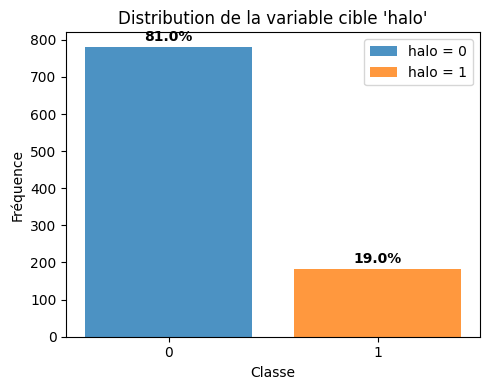

In [9]:
import matplotlib.pyplot as plt

y = df["halo"].astype(int)

freq = y.value_counts().sort_index()
pct = y.value_counts(normalize=True).sort_index() * 100

resume = pd.DataFrame({"Fréquence": freq, "Pourcentage": pct.round(2)})
print(resume)

# Graphique
colors = ["#1f77b4", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(5,4))

# On trace barre par barre avec légende personnalisée
for i, (classe, valeur) in enumerate(freq.items()):
    ax.bar(i, valeur, color=colors[i], alpha=0.8, label=f"halo = {classe}")
    ax.text(i, valeur + max(freq)*0.01, f"{pct.iloc[i]:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Distribution de la variable cible 'halo'")
ax.set_xlabel("Classe")
ax.set_ylabel("Fréquence")
ax.legend(title=None)

plt.xticks(range(len(freq)), freq.index)
plt.tight_layout()
plt.show()

##  Séparation train/test stratifiée

### Mesure de sureté

In [10]:
import numpy as np

# On vérifie d'abord les souches présentes dans le dataset
souches_productrices = set(df["productrice"].unique())
souches_cibles = set(df["cible"].unique())

# Comptage
print(f" Nombre total de souches (productrices) : {len(souches_productrices)}")
print(f" Nombre total de souches (cibles)       : {len(souches_cibles)}")

# Vérification de correspondance
if souches_productrices == souches_cibles:
    print("\n Les mêmes souches apparaissent comme productrices et comme cibles.")
else:
    diff_prod = souches_productrices - souches_cibles
    diff_cibl = souches_cibles - souches_productrices
    print("\n Les listes ne sont pas identiques :")
    if diff_prod:
        print(f"   → Souches présentes uniquement comme productrices : {sorted(list(diff_prod))}")
    if diff_cibl:
        print(f"   → Souches présentes uniquement comme cibles       : {sorted(list(diff_cibl))}")

 Nombre total de souches (productrices) : 34
 Nombre total de souches (cibles)       : 34

 Les mêmes souches apparaissent comme productrices et comme cibles.


### Shuffle

In [11]:
from sklearn.utils import shuffle

# Split train/test par productrice
# Le but c'est de créer un split réaliste et équilibré,
# sans fuite d’information entre train et test.

test_frac = 0.5  # proportion de souches productrices pour le test
rng = np.random.default_rng(42)

assert {"cible", "productrice", "halo"}.issubset(df.columns), "Colonnes manquantes dans df"

# Mélange aléatoirement des observations (comme train_test_split)
df_shuffled = shuffle(df, random_state=42).reset_index(drop=True)
print(f" df mélangé : {len(df_shuffled)} lignes")

# Calcul de la proportion globale de halos
p_halo_global = df["halo"].mean()
print(f" Taux global de halo positif : {p_halo_global:.2%}")

# Préparation pour stratification au niveau des productrices

# On calcule le taux de halo pour chaque productrice
df_prod = (
    df_shuffled.groupby("productrice", as_index=False)
    .agg(taux_halo=("halo", "mean"), n_obs=("halo", "size"))
)

# On crée une "classe de stratification" en fonction du taux de halo
# (ex: productrices fortement actives vs peu actives)
df_prod["strat_class"] = pd.qcut(
    df_prod["taux_halo"],
    q=3,  # on découpe en 3 quantiles pour capturer la variabilité
    duplicates="drop",
    labels=False
)

# Sélection des souches TEST stratifiée et mélangée aléatoirement
souches_test = []
for c in sorted(df_prod["strat_class"].unique()):
    subset = df_prod[df_prod["strat_class"] == c]
    n_test_c = max(1, int(len(subset) * test_frac))
    chosen = rng.choice(subset["productrice"], size=n_test_c, replace=False)
    souches_test.extend(chosen)

souches_test = np.array(sorted(set(souches_test)))
souches_train = np.setdiff1d(df_prod["productrice"], souches_test)

print(f"\n {len(souches_test)} productrices test sélectionnées ({100*test_frac:.0f}%)")
print(f" {len(souches_train)} productrices restantes pour le train")

 df mélangé : 964 lignes
 Taux global de halo positif : 18.98%

 16 productrices test sélectionnées (50%)
 18 productrices restantes pour le train


### Split

In [12]:
# Construction des masques pour répartir les observations entre TRAIN / TEST
train_mask = (
    df["productrice"].isin(souches_train)
    & df["cible"].isin(souches_train)
)
test_mask = (
    df["productrice"].isin(souches_test)
    & df["cible"].isin(souches_train)
)

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

# Vérifications de cohérence
assert not set(df_train["productrice"]).intersection(souches_test), " Souche test détectée dans le TRAIN"
assert all(df_test["cible"].isin(souches_train)), " Cible non-TRAIN détectée dans le TEST"
assert not set(df_train["couple"]).intersection(df_test["couple"]), " Couple présent dans les deux jeux"

print(f"\n Train : {len(df_train)} couples ({len(df_train)/len(df):.1%})")
print(f" Test  : {len(df_test)} couples ({len(df_test)/len(df):.1%})")

# Extraction des sous-ensembles (X/y)
cols_to_drop = ["halo", "cible", "productrice", "couple"] if "couple" in df.columns else ["halo", "cible", "productrice"]

X_train = df_train.drop(columns=cols_to_drop, errors="ignore")
y_train = df_train["halo"]

X_test  = df_test.drop(columns=cols_to_drop, errors="ignore")
y_test  = df_test["halo"]

print(f"\n X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f" y_train : {y_train.shape}, y_test : {y_test.shape}")

# Vérification de la stratification (distribution halo)
def halo_dist(y, label):
    vc = y.value_counts(normalize=True).sort_index()
    print(f"{label} → halo=0 : {vc.get(0,0):.2%} | halo=1 : {vc.get(1,0):.2%}")

print("\nDistribution des halos :")
halo_dist(y_train, "TRAIN")
halo_dist(y_test,  "TEST")
halo_dist(df["halo"], "GLOBAL")

print("\nStratification respectée (distributions similaires)")


 Train : 268 couples (27.8%)
 Test  : 249 couples (25.8%)

 X_train : (268, 9358), X_test : (249, 9358)
 y_train : (268,), y_test : (249,)

Distribution des halos :
TRAIN → halo=0 : 79.85% | halo=1 : 20.15%
TEST → halo=0 : 81.53% | halo=1 : 18.47%
GLOBAL → halo=0 : 81.02% | halo=1 : 18.98%

Stratification respectée (distributions similaires)


# ML

## Implémentation d'un DecisionTree

### Installation de scikit-optimize

In [13]:
!pip install scikit-optimize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 KB 3.1 MB/s eta 0:00:00


## Decision Tree de base

### Entrainement

In [14]:
import random
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate

# OPTIMISATION D'UN ARBRE DE DÉCISION (Average Precision)

# Création du dictionnaire des hyper param pour la méthode Random ou GridSearch
param_dict = {
    'criterion': ['entropy'], # Le critère de split des arbres
    'max_depth': [5, 6, 7, 8],  # Profondeur maximum de l'arbre
    'min_samples_split': [10, 15, 20, 25], # Nombre d'observations mimnimum pour créer un split
    'min_samples_leaf': [7, 8, 9, 10],     # Nombre d'observations minimum dans une feuille
    'max_features': [0.1, 0.2, 0.3]
}

# Création  du dictionnaire de recherche pour la méthode d'optimisation bayesienne
clf = DecisionTreeClassifier(random_state=42)

# Définition des paramètres avec des lois de probabilités
param_dict_bayes = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(3,15),
    'min_samples_split': Integer(2,50),
    'min_samples_leaf': Integer(1,20),
    'max_features': Real(0,0.5, prior='uniform')
}

# Grilles des paramètres
NB_ITER = 5 # Nombre d'itérations maximum pour le Random et l'optimisation Bayesienne

# Définition de la Cross-Validation cohérente avec ta construction
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = df_train["productrice"]

# Tirage aléatoire d'une combinaison de paramètre
from sklearn.model_selection import cross_validate

# Définition de la fonction de recherche
def random_parameter(clf,param_dict,n_iter,X_train,y_train,nb_cv) :
    res = pd.DataFrame()
    compt = 0
    num_iter = []
    avgp=[]
    param = []
    while compt < n_iter :
        compt = compt + 1
        params = {key: random.sample(value, 1)[0] for key, value in param_dict.items()}
        clf.set_params(**params)
        scores = cross_validate(
            clf, X_train, y_train, cv=cv, groups=groups,
            scoring=['average_precision']
        )
        num_iter.append(compt)
        param.append(params)
        avgp.append(scores['test_average_precision'].mean())

    res["Num_ITER"] = num_iter
    res["Param"] = param
    res["Average_Precision"] = avgp

    return res


from timeit import default_timer as timer
start = timer()
Random_Res_Tree = random_parameter(DecisionTreeClassifier(random_state=42),
                                   param_dict,NB_ITER,X_train,y_train,5)
delais = timer()- start
print(" #### RECHERCHE ALEATOIRE #### ")
print(" \n Durée de recherche en seconde :")
print(delais)
Random_Res_Tree.sort_values('Average_Precision', ascending = False, inplace = True)
Random_Res_Tree.head()

# Les meilleurs paramètres
best_param_random_search = list(Random_Res_Tree["Param"])[0]
print("\n Paramètres recherche aléatoire : ")
print(best_param_random_search)

print("\n Résultats recherche aléatoire : " + str(Random_Res_Tree['Average_Precision'].max()))


# Grid Search
from sklearn.model_selection import GridSearchCV

start = timer()
Grid_Search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dict,
    scoring='average_precision',
    cv=cv
)
Grid_Search.fit(X_train,y_train,groups=groups)
delais = timer()- start
print("\n #### RECHERCHE GRID SEARCH #### ")
print(" \n Durée de recherche en minute :")
print(delais/60)
print("\n Paramètres grid search : ")
best_param_gid_search = Grid_Search.best_params_
print(best_param_gid_search)
best_score_grid_search = Grid_Search.best_score_
print("\n Résultats grid search  : " + str(best_score_grid_search))

# Optimisation bayésienne
opt = BayesSearchCV(
    clf,
    param_dict_bayes,
    n_iter=NB_ITER,
    cv=cv,
    scoring='average_precision',
    random_state=42
)
start = timer()
opt.fit(X_train, y_train, groups=groups)
delais = timer()- start

print("\n #### RECHERCHE OPTIMISATION #### ")
print(" \n Durée de recherche en seconde :")
print(delais)
print("\n Paramètres recherche Bayes : ")
best_param_opti_bayes = opt.best_params_
print(best_param_opti_bayes)
best_score_opti_bayes = opt.best_score_
print("\n Résultats recherche Bayes  : " + str(best_score_opti_bayes))

 #### RECHERCHE ALEATOIRE #### 
 
 Durée de recherche en seconde :
1.2813661489999504

 Paramètres recherche aléatoire : 
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 0.2}

 Résultats recherche aléatoire : 0.7674775173423922

 #### RECHERCHE GRID SEARCH #### 
 
 Durée de recherche en minute :
0.7862106459833285

 Paramètres grid search : 
{'criterion': 'entropy', 'max_depth': 5, 'max_features': 0.3, 'min_samples_leaf': 10, 'min_samples_split': 25}

 Résultats grid search  : 0.786927581066732

 #### RECHERCHE OPTIMISATION #### 
 
 Durée de recherche en seconde :
1.3589415669994196

 Paramètres recherche Bayes : 
OrderedDict([('criterion', 'gini'), ('max_depth', 12), ('max_features', 0.46643399942391695), ('min_samples_leaf', 7), ('min_samples_split', 34)])

 Résultats recherche Bayes  : 0.8063600878325572


### Metrique d'evaluation

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# DT avec hyperparam grid search
dt_final = DecisionTreeClassifier(**best_param_opti_bayes, random_state=42)

# Entraînement sur train
dt_final.fit(X_train, y_train)

# Prédictions sur test
y_pred = dt_final.predict(X_test)
y_proba = dt_final.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification report :\n", classification_report(y_test, y_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC :", roc_auc_score(y_test, y_proba))

Accuracy : 0.9076305220883534

Classification report :
               precision    recall  f1-score   support

           0       0.94      0.95      0.94       203
           1       0.76      0.74      0.75        46

    accuracy                           0.91       249
   macro avg       0.85      0.84      0.85       249
weighted avg       0.91      0.91      0.91       249


Matrice de confusion :
 [[192  11]
 [ 12  34]]

ROC AUC : 0.919575926322553


## Avec pruning

### Parametre de regularisation

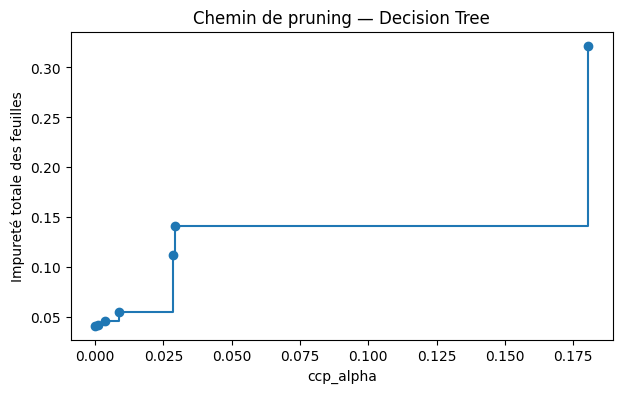

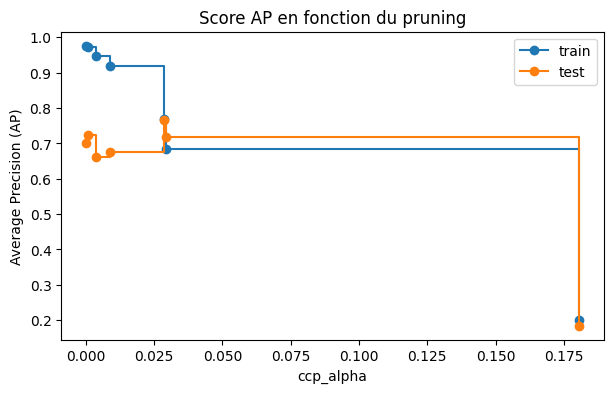

 Meilleur ccp_alpha selon l'Average Precision : 0.02864
 Score AP test correspondant : 0.766


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score

# Récupération des meilleurs paramètres du GridSearch (hors ccp_alpha)
#best_param_gid_search = Grid_Search.best_params_

# Calcul du chemin d’élagage (cost-complexity pruning path)
dt_base = DecisionTreeClassifier(**best_param_opti_bayes, random_state=42)
path = dt_base.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Visualisation du trade-off complexité / impureté
plt.figure(figsize=(7,4))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Impureté totale des feuilles")
plt.title("Chemin de pruning — Decision Tree")
plt.show()

# Entraînement d’un arbre pour chaque alpha
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(**best_param_opti_bayes, ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Calcul du score d'Average Precision
train_scores = []
test_scores  = []

for clf in clfs:
    y_pred_train = clf.predict_proba(X_train)[:, 1]
    y_pred_test  = clf.predict_proba(X_test)[:, 1]

    ap_train = average_precision_score(y_train, y_pred_train)
    ap_test  = average_precision_score(y_test, y_pred_test)

    train_scores.append(ap_train)
    test_scores.append(ap_test)

# Visualisation du score AP vs ccp_alpha
plt.figure(figsize=(7,4))
plt.plot(ccp_alphas, train_scores, marker='o', label='train', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores,  marker='o', label='test',  drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Average Precision (AP)")
plt.title("Score AP en fonction du pruning")
plt.legend()
plt.show()

# Sélection du meilleur alpha selon le score test
best_alpha = ccp_alphas[np.argmax(test_scores)]
best_ap    = max(test_scores)

print(f" Meilleur ccp_alpha selon l'Average Precision : {best_alpha:.5f}")
print(f" Score AP test correspondant : {best_ap:.3f}")

### Metrique d'evaluation

In [17]:
# Entraînement final du modèle élagué
dt_pruned = DecisionTreeClassifier(**best_param_opti_bayes,
                                   ccp_alpha=best_alpha,
                                   random_state=42)
dt_pruned.fit(X_train, y_train)

# Prédictions et évaluation
y_pred = dt_pruned.predict(X_test)
y_proba = dt_pruned.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("\n Évaluation du modèle élagué")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification report :\n", classification_report(y_test, y_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC :", roc_auc_score(y_test, y_proba))


 Évaluation du modèle élagué
Accuracy : 0.9236947791164659

Classification report :
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       203
           1       0.89      0.67      0.77        46

    accuracy                           0.92       249
   macro avg       0.91      0.83      0.86       249
weighted avg       0.92      0.92      0.92       249


Matrice de confusion :
 [[199   4]
 [ 15  31]]

ROC AUC : 0.9083315485114585


## Decision Tree avec balanced class

### Entrainement

In [18]:
from timeit import default_timer as timer

# Grille pour Random/Grid Search
param_dict = {
    'criterion': ['entropy'],
    'max_depth': [6, 7, 8],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [7, 8, 9],
    'max_features': [0.1, 0.2, 0.3],
    'class_weight': ['balanced', None]
}

# Grille pour BayesSearch
param_dict_bayes = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(3, 15),
    'min_samples_split': Integer(2, 50),
    'min_samples_leaf': Integer(1, 20),
    'max_features': Real(0, 0.5, prior='uniform'),
    'class_weight': Categorical(['balanced', None])
}

NB_ITER = 5

# Définition du schéma de CV cohérent avec ta logique biologique
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = df_train["productrice"]

# Random Search
def random_parameter(clf, param_dict, n_iter, X_train, y_train, nb_cv):
    res = pd.DataFrame()
    compt, num_iter, ap, param = 0, [], [], []
    while compt < n_iter:
        compt += 1
        params = {k: random.sample(v, 1)[0] for k, v in param_dict.items()}
        clf.set_params(**params)
        scores = cross_validate(
            clf, X_train, y_train,
            cv=cv, groups=groups,
            scoring=['average_precision']
        )
        num_iter.append(compt)
        param.append(params)
        ap.append(scores['test_average_precision'].mean())
    res["Num_ITER"] = num_iter
    res["Param"] = param
    res["Auc"] = ap
    return res


start = timer()
Random_Res_Tree = random_parameter(DecisionTreeClassifier(), param_dict, NB_ITER, X_train, y_train, 5)
delais = timer() - start
print(" #### RECHERCHE ALEATOIRE #### ")
print("Durée (s):", delais)
Random_Res_Tree.sort_values('Auc', ascending=False, inplace=True)
best_param_random_search = list(Random_Res_Tree["Param"])[0]
print("Paramètres random :", best_param_random_search)
print("Best AP :", Random_Res_Tree['Auc'].max())

# Grid Search
start = timer()
Grid_Search = GridSearchCV(
    DecisionTreeClassifier(),
    param_dict,
    scoring='average_precision',
    cv=cv
)
Grid_Search.fit(X_train, y_train, groups=groups)
delais = timer() - start
print("\n#### GRID SEARCH ####")
print("Durée (min):", delais / 60)
best_param_gid_search_bal = Grid_Search.best_params_
best_score_grid_search_bal = Grid_Search.best_score_
print("Best params:", best_param_gid_search_bal)
print("Best AP:", best_score_grid_search_bal)

# BayesSearch
clf = DecisionTreeClassifier()
opt = BayesSearchCV(
    clf,
    param_dict_bayes,
    n_iter=NB_ITER,
    cv=cv,
    scoring='average_precision',
    random_state=42
)
start = timer()
opt.fit(X_train, y_train, groups=groups)
delais = timer() - start
print("\n#### BAYES SEARCH ####")
print("Durée (s):", delais)
best_param_opti_bayes_bal = opt.best_params_
best_score_opti_bayes_bal = opt.best_score_
print("Best params:", best_param_opti_bayes_bal)
print("Best AP:", best_score_opti_bayes_bal)

 #### RECHERCHE ALEATOIRE #### 
Durée (s): 1.1379872649995377
Paramètres random : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.1, 'class_weight': None}
Best AP : 0.7803133512419804

#### GRID SEARCH ####
Durée (min): 0.6652591015000022
Best params: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 0.2, 'min_samples_leaf': 9, 'min_samples_split': 15}
Best AP: 0.7956305605779826

#### BAYES SEARCH ####
Durée (s): 1.544230702999812
Best params: OrderedDict([('class_weight', None), ('criterion', 'gini'), ('max_depth', 10), ('max_features', 0.4013823905781553), ('min_samples_leaf', 11), ('min_samples_split', 7)])
Best AP: 0.7117549293552756


### Metrique Evaluation

In [19]:
# Évaluation du modèle issu du Grid Search

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Modèle final avec les hyperparamètres optimaux du GridSearchCV
dt_final = DecisionTreeClassifier(**best_param_gid_search_bal, random_state=42)
dt_final.fit(X_train, y_train)

# Prédictions
y_pred = dt_final.predict(X_test)
y_proba = dt_final.predict_proba(X_test)[:, 1]

print("\nÉvaluation du modèle Grid Search")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification report :\n", classification_report(y_test, y_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC :", roc_auc_score(y_test, y_proba))


Évaluation du modèle Grid Search
Accuracy : 0.8514056224899599

Classification report :
               precision    recall  f1-score   support

           0       0.92      0.89      0.91       203
           1       0.58      0.67      0.63        46

    accuracy                           0.85       249
   macro avg       0.75      0.78      0.77       249
weighted avg       0.86      0.85      0.86       249


Matrice de confusion :
 [[181  22]
 [ 15  31]]

ROC AUC : 0.9074212893553223


## Comparaison des 3 variantes de DecisionTreeClassifier

### Prediction

In [20]:
# Reconstruction des 3 variantes de Decision Tree

# Modèle de base (issu du Grid Search standard)
DT_Base = DecisionTreeClassifier(**best_param_opti_bayes, random_state=42)
DT_Base.fit(X_train, y_train)

# Modèle régularisé (avec élagage optimal)
DT_Reg = DecisionTreeClassifier(**best_param_opti_bayes, ccp_alpha=best_alpha, random_state=42)
DT_Reg.fit(X_train, y_train)


# Modèle équilibré (class_weight='balanced')
DT_Bal = DecisionTreeClassifier(**best_param_gid_search_bal, random_state=42)
DT_Bal.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,7
,min_samples_split,15
,min_samples_leaf,9
,min_weight_fraction_leaf,0.0
,max_features,0.2
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Courbe AUC - Precision Rappel et metriques

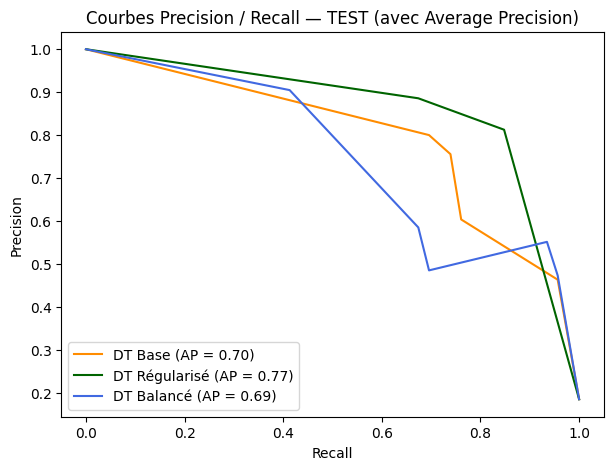


SYNTHÈSE COMPLÈTE DES 3 VARIANTES DE DECISION TREE


,Modèle,AUC_Train,AUC_Test,AP_Train,AP_Test,Precision_Test,Recall_Test,F1_Test
0,DT_Base,0.995,0.920,0.976,0.701,0.756,0.739,0.747
1,DT_Régularisé,0.871,0.908,0.769,0.766,0.886,0.674,0.765
2,DT_Balancé,0.993,0.907,0.964,0.687,0.585,0.674,0.626


In [21]:
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    f1_score, recall_score, precision_score
)
import matplotlib.pyplot as plt
import pandas as pd

# COURBE PRECISION / RECALL — TEST avec AP ============

prec_test_base, rec_test_base, _ = precision_recall_curve(y_test, DT_Base.predict_proba(X_test)[:, 1])
prec_test_reg,  rec_test_reg,  _ = precision_recall_curve(y_test, DT_Reg.predict_proba(X_test)[:, 1])
prec_test_bal,  rec_test_bal,  _ = precision_recall_curve(y_test, DT_Bal.predict_proba(X_test)[:, 1])

ap_test_base = average_precision_score(y_test, DT_Base.predict_proba(X_test)[:, 1])
ap_test_reg  = average_precision_score(y_test, DT_Reg.predict_proba(X_test)[:, 1])
ap_test_bal  = average_precision_score(y_test, DT_Bal.predict_proba(X_test)[:, 1])

plt.figure(figsize=(7,5))
plt.plot(rec_test_base, prec_test_base, label=f"DT Base (AP = {ap_test_base:.2f})", color='darkorange')
plt.plot(rec_test_reg,  prec_test_reg,  label=f"DT Régularisé (AP = {ap_test_reg:.2f})", color='darkgreen')
plt.plot(rec_test_bal,  prec_test_bal,  label=f"DT Balancé (AP = {ap_test_bal:.2f})", color='royalblue')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbes Precision / Recall — TEST (avec Average Precision)")
plt.legend(loc='lower left')
plt.show()


# TABLEAU SYNTHÉTIQUE COMPLET — 3 VARIANTES ============

# === Scores complémentaires sur le TRAIN ===
auc_train_base = roc_auc_score(y_train, DT_Base.predict_proba(X_train)[:, 1])
auc_train_reg  = roc_auc_score(y_train, DT_Reg.predict_proba(X_train)[:, 1])
auc_train_bal  = roc_auc_score(y_train, DT_Bal.predict_proba(X_train)[:, 1])

ap_train_base  = average_precision_score(y_train, DT_Base.predict_proba(X_train)[:, 1])
ap_train_reg   = average_precision_score(y_train, DT_Reg.predict_proba(X_train)[:, 1])
ap_train_bal   = average_precision_score(y_train, DT_Bal.predict_proba(X_train)[:, 1])

# Scores complémentaires sur le TEST
auc_test_base = roc_auc_score(y_test, DT_Base.predict_proba(X_test)[:, 1])
auc_test_reg  = roc_auc_score(y_test, DT_Reg.predict_proba(X_test)[:, 1])
auc_test_bal  = roc_auc_score(y_test, DT_Bal.predict_proba(X_test)[:, 1])

# Scores de classification test
y_pred_base = DT_Base.predict(X_test)
y_pred_reg  = DT_Reg.predict(X_test)
y_pred_bal  = DT_Bal.predict(X_test)

precision_base = precision_score(y_test, y_pred_base)
recall_base    = recall_score(y_test, y_pred_base)
f1_base        = f1_score(y_test, y_pred_base)

precision_reg = precision_score(y_test, y_pred_reg)
recall_reg    = recall_score(y_test, y_pred_reg)
f1_reg        = f1_score(y_test, y_pred_reg)

precision_bal = precision_score(y_test, y_pred_bal)
recall_bal    = recall_score(y_test, y_pred_bal)
f1_bal        = f1_score(y_test, y_pred_bal)

# Construction du tableau récapitulatif
summary = pd.DataFrame({
    "Modèle": ["DT_Base", "DT_Régularisé", "DT_Balancé"],
    "AUC_Train": [auc_train_base, auc_train_reg, auc_train_bal],
    "AUC_Test":  [auc_test_base,  auc_test_reg,  auc_test_bal],
    "AP_Train":  [ap_train_base,  ap_train_reg,  ap_train_bal],
    "AP_Test":   [ap_test_base,   ap_test_reg,   ap_test_bal],
    "Precision_Test": [precision_base, precision_reg, precision_bal],
    "Recall_Test":    [recall_base, recall_reg, recall_bal],
    "F1_Test":        [f1_base, f1_reg, f1_bal]
})

print("\nSYNTHÈSE COMPLÈTE DES 3 VARIANTES DE DECISION TREE")
display(summary.round(3))

## Implementation d'un Random Forest

### Entrainement

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold

param_dict_bayes_RF = {
    'n_estimators': Integer(200, 400),
    'criterion': Categorical(['entropy']),
    'max_depth': Integer(5, 15),
    'min_samples_split': Integer(8, 35),
    'min_samples_leaf': Integer(5, 30),
    'max_features': Categorical([0.01, 0.05, 0.1, 0.2]),
    'bootstrap': Categorical([True]),
    'random_state': Categorical([42]),
    'n_jobs': Categorical([-1]),
}

# Définition de la Cross-Validation groupée et stratifiée
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = df_train["productrice"]

opt = BayesSearchCV(
    RandomForestClassifier(),
    param_dict_bayes_RF,
    n_iter=NB_ITER,
    cv=cv,
    scoring='average_precision',
    random_state=42
)

start = timer()
opt.fit(X_train, y_train, groups=groups)
delais = timer()- start
best_param_opti_bayes = opt.best_params_
best_score_opti_bayes = opt.best_score_
all_result_opti_bayes = opt.cv_results_

print(" #### RECHERCHE DES PARAMETRES OPTIMAUX POUR LE RANDOM FOREST #### ")
print(" \n Durée de recherche en seconde :")
print(delais)
print("\n Paramètres optimaux : ")
best_param_opti_bayes = opt.best_params_
print(best_param_opti_bayes)
best_score_opti_bayes = opt.best_score_
print("\n Résultats  : " + str(best_score_opti_bayes))

 #### RECHERCHE DES PARAMETRES OPTIMAUX POUR LE RANDOM FOREST #### 
 
 Durée de recherche en seconde :
7.735756423000566

 Paramètres optimaux : 
OrderedDict([('bootstrap', True), ('criterion', 'entropy'), ('max_depth', 6), ('max_features', 0.05), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 231), ('n_jobs', -1), ('random_state', 42)])

 Résultats  : 0.8756256978377248


### Metrique d'evaluation

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
    f1_score, recall_score, precision_score
)
from sklearn.ensemble import RandomForestClassifier

# Meilleur modèle trouvé par la recherche bayésienne
rf_final = RandomForestClassifier(**best_param_opti_bayes)
rf_final.fit(X_train, y_train)

# Prédictions et probabilités
y_pred_train = rf_final.predict(X_train)
y_proba_train = rf_final.predict_proba(X_train)[:, 1]
y_pred_test  = rf_final.predict(X_test)
y_proba_test = rf_final.predict_proba(X_test)[:, 1]

# Scores
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
auc_train = roc_auc_score(y_train, y_proba_train)
auc_test  = roc_auc_score(y_test,  y_proba_test)
ap_train  = average_precision_score(y_train, y_proba_train)
ap_test   = average_precision_score(y_test,  y_proba_test)
f1_train  = f1_score(y_train, y_pred_train)
f1_test   = f1_score(y_test, y_pred_test)
rec_train = recall_score(y_train, y_pred_train)
rec_test  = recall_score(y_test, y_pred_test)
prec_train = precision_score(y_train, y_pred_train)
prec_test  = precision_score(y_test, y_pred_test)

# Tableau récapitulatif
metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [acc_train, acc_test],
    "ROC-AUC": [auc_train, auc_test],
    "PR-AUC": [ap_train, ap_test],
    "Precision": [prec_train, prec_test],
    "Recall": [rec_train, rec_test],
    "F1-score": [f1_train, f1_test]
})
print("\nTableau récapitulatif des métriques")
print(metrics_table.round(3))

# Matrice de confusion (test)
cm = confusion_matrix(y_test, y_pred_test)
print("\nMatrice de confusion (test) :\n", cm)
print("\nClassification report (test) :\n", classification_report(y_test, y_pred_test))


Tableau récapitulatif des métriques
  Dataset  Accuracy  ROC-AUC  PR-AUC  Precision  Recall  F1-score
0   Train     0.948    0.994   0.976      0.917   0.815     0.863
1    Test     0.936    0.965   0.877      0.812   0.848     0.830

Matrice de confusion (test) :
 [[194   9]
 [  7  39]]

Classification report (test) :
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       203
           1       0.81      0.85      0.83        46

    accuracy                           0.94       249
   macro avg       0.89      0.90      0.90       249
weighted avg       0.94      0.94      0.94       249



### Courbe ROC et Precision Rappel

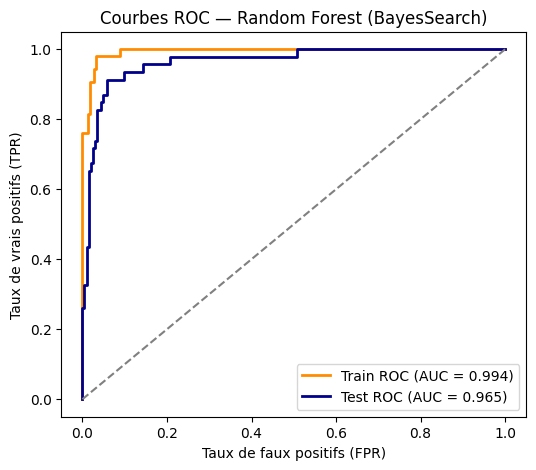

In [24]:
# Courbes ROC (train/test)
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_proba_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test  = auc(fpr_test,  tpr_test)

plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2,
         label=f'Train ROC (AUC = {roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkblue', lw=2,
         label=f'Test ROC (AUC = {roc_auc_test:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC — Random Forest (BayesSearch)')
plt.legend(loc="lower right")
plt.show()

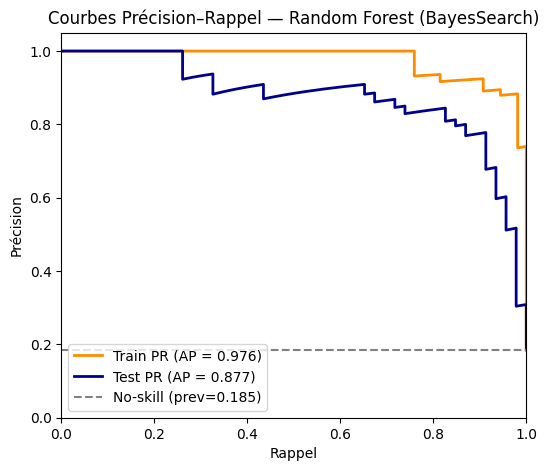

In [25]:
# Courbes PR-AUC (train/test)
prec_train, rec_train, _ = precision_recall_curve(y_train, y_proba_train)
prec_test,  rec_test,  _ = precision_recall_curve(y_test,  y_proba_test)
ap_train = average_precision_score(y_train, y_proba_train)
ap_test  = average_precision_score(y_test,  y_proba_test)
base_train = y_train.mean()
base_test  = y_test.mean()

plt.figure(figsize=(6,5))
plt.plot(rec_train, prec_train, color='darkorange', lw=2,
         label=f'Train PR (AP = {ap_train:.3f})')
plt.plot(rec_test, prec_test, color='darkblue', lw=2,
         label=f'Test PR (AP = {ap_test:.3f})')
plt.hlines(base_test, 0, 1, colors='gray', linestyles='--',
           label=f'No-skill (prev={base_test:.3f})')
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Courbes Précision–Rappel — Random Forest (BayesSearch)')
plt.legend(loc='lower left')
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.show()

## XGBoost

### Entrainement

In [27]:
import sys
!{sys.executable} -m pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 37.5 MB/s eta 0:00:00m eta 0:00:010:01:01


In [28]:
import xgboost as xgb

# Grille SANS balanced class
param_dict_XGB = {
    'objective': Categorical(['binary:logistic']),
    'booster': Categorical(['gbtree']),
    'learning_rate': Real(0.1, 0.3, prior='uniform'),
    'n_estimators': Integer(200, 400),
    'max_depth': Integer(2, 5),
    'min_child_weight': Integer(1, 5),
    'gamma': Real(1.0, 2.0, prior='uniform'),
    'subsample': Real(0.6, 0.9, prior='uniform'),
    'colsample_bytree': Real(0.2, 0.5, prior='uniform'),
    'reg_lambda': Real(0.5, 3.0, prior='log-uniform'),
    'reg_alpha': Real(1e-6, 1.0, prior='log-uniform'),
    'random_state': [42]
}

NB_ITER = 25

# Définition de la Cross-Validation cohérente
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = df_train["productrice"]

opt = BayesSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='aucpr',
        use_label_encoder=False,
        tree_method='hist',
        verbosity=0
    ),
    search_spaces=param_dict_XGB,
    n_iter=NB_ITER,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42
)

# Exécution
start = timer()
opt.fit(X_train, y_train, groups=groups)
delais = timer() - start

print("#### RECHERCHE DES PARAMÈTRES OPTIMAUX POUR XGBOOST ####")
print(f"Durée : {delais:.1f} s")
print("Paramètres optimaux :")
print(opt.best_params_)
print(f"Meilleur score (AP) : {opt.best_score_:.4f}")

# Modèle final
xgb_clf = xgb.XGBClassifier(
    **opt.best_params_,
    eval_metric='aucpr',
    use_label_encoder=False
)
xgb_clf.fit(X_train, y_train)

#### RECHERCHE DES PARAMÈTRES OPTIMAUX POUR XGBOOST ####
Durée : 120.6 s
Paramètres optimaux :
OrderedDict([('booster', 'gbtree'), ('colsample_bytree', 0.3935611223119711), ('gamma', 1.2439301452494589), ('learning_rate', 0.1427737641424302), ('max_depth', 5), ('min_child_weight', 1), ('n_estimators', 367), ('objective', 'binary:logistic'), ('random_state', 42), ('reg_alpha', 0.0009009708091829499), ('reg_lambda', 0.8801428483417925), ('subsample', 0.9)])
Meilleur score (AP) : 0.8674


/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:40:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.3935611223119711
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


### Metrique d'evaluation

In [29]:
# Prédictions
y_pred_train = xgb_clf.predict(X_train)
y_proba_train = xgb_clf.predict_proba(X_train)[:, 1]
y_pred_test  = xgb_clf.predict(X_test)
y_proba_test = xgb_clf.predict_proba(X_test)[:, 1]

# Scores
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
ap_train  = average_precision_score(y_train, y_proba_train)
ap_test   = average_precision_score(y_test,  y_proba_test)
auc_train = auc(*roc_curve(y_train, y_proba_train)[:2])
auc_test  = auc(*roc_curve(y_test,  y_proba_test)[:2])
f1_train  = f1_score(y_train, y_pred_train)
f1_test   = f1_score(y_test, y_pred_test)
rec_train = recall_score(y_train, y_pred_train)
rec_test  = recall_score(y_test, y_pred_test)
prec_train = precision_score(y_train, y_pred_train)
prec_test  = precision_score(y_test, y_pred_test)

# Tableau récapitulatif
metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [acc_train, acc_test],
    "ROC-AUC": [auc_train, auc_test],
    "PR-AUC (AP)": [ap_train, ap_test],
    "Precision": [prec_train, prec_test],
    "Recall": [rec_train, rec_test],
    "F1-score": [f1_train, f1_test]
})
print("\nTABLEAU DES MÉTRIQUES (XGBoost)")
print(metrics_table.round(3))

# Matrice de confusion (Test)
cm = confusion_matrix(y_test, y_pred_test)
print("\nMatrice de confusion (test) :\n", cm)
print("\nClassification report (test) :\n", classification_report(y_test, y_pred_test))


TABLEAU DES MÉTRIQUES (XGBoost)
  Dataset  Accuracy  ROC-AUC  PR-AUC (AP)  Precision  Recall  F1-score
0   Train     0.996    1.000        1.000      1.000   0.981     0.991
1    Test     0.932    0.966        0.858      0.774   0.891     0.828

Matrice de confusion (test) :
 [[191  12]
 [  5  41]]

Classification report (test) :
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       203
           1       0.77      0.89      0.83        46

    accuracy                           0.93       249
   macro avg       0.87      0.92      0.89       249
weighted avg       0.94      0.93      0.93       249



### Courbe ROC - Precision Rappel

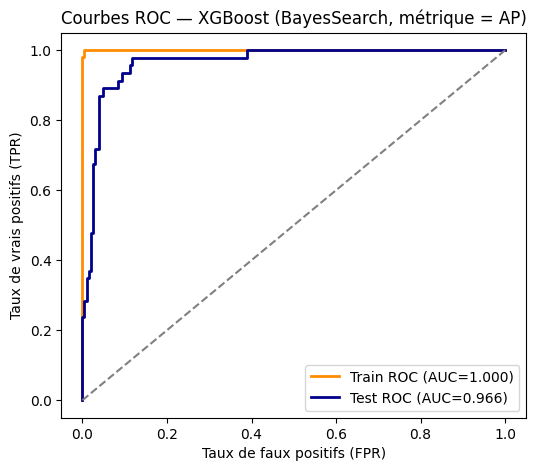

In [30]:
# Courbes ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_proba_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test  = auc(fpr_test,  tpr_test)

plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2,
         label=f'Train ROC (AUC={roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkblue', lw=2,
         label=f'Test ROC (AUC={roc_auc_test:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC — XGBoost (BayesSearch, métrique = AP)')
plt.legend(loc="lower right")
plt.show()

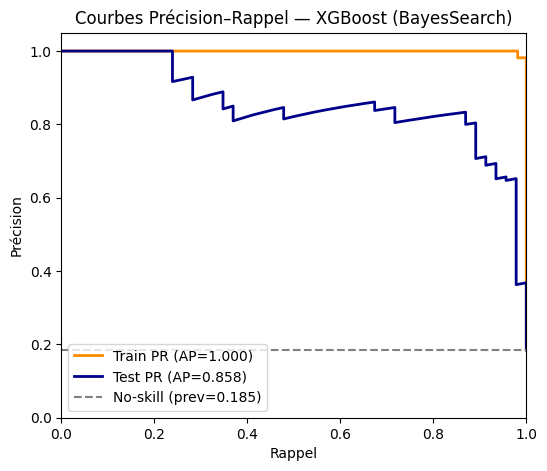

In [31]:
# Courbes Précision–Rappel
prec_train_curve, rec_train_curve, _ = precision_recall_curve(y_train, y_proba_train)
prec_test_curve, rec_test_curve, _ = precision_recall_curve(y_test,  y_proba_test)
base_test = y_test.mean()

plt.figure(figsize=(6,5))
plt.plot(rec_train_curve, prec_train_curve, color='darkorange', lw=2,
         label=f'Train PR (AP={ap_train:.3f})')
plt.plot(rec_test_curve, prec_test_curve, color='darkblue', lw=2,
         label=f'Test PR (AP={ap_test:.3f})')
plt.hlines(base_test, 0, 1, colors='gray', linestyles='--',
           label=f'No-skill (prev={base_test:.3f})')
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Courbes Précision–Rappel — XGBoost (BayesSearch)')
plt.legend(loc='lower left')
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.show()

In [46]:
#import sys
#!{sys.executable} -m pip install shap

### Importance des features de xgBoost

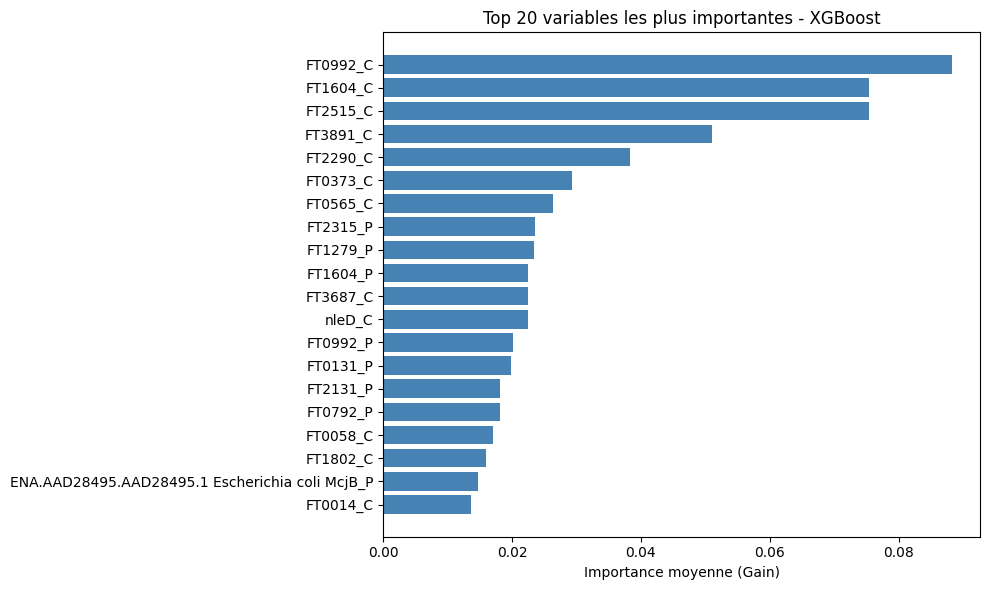

In [32]:
# Importance des features (XGBoost)
# Récupération des importances (gain moyen par split)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.head(20)['Feature'][::-1],
    importance_df.head(20)['Importance'][::-1],
    color='steelblue'
)
plt.xlabel("Importance moyenne (Gain)")
plt.title("Top 20 variables les plus importantes - XGBoost")
plt.tight_layout()
plt.show()

## Stacking classifier

### Entrainement

In [33]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Définitions des modèles de base (déjà entraînés)
estimators = [
    ('RF', rf_final),
    ('XGB', xgb_clf),
    ('Tree', DT_Reg)
]

# Paramètres à tester pour le métamodèle
param_stacking = {
    'cv': [5],
    'stack_method': ['auto'],  # utilisera predict_proba
    'final_estimator': [
        LogisticRegression(
            solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42
        ),
        DecisionTreeClassifier(
            max_depth=4, min_samples_leaf=5, random_state=42
        )
    ]
}

# Définition de la CV groupée et stratifiée
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups = df_train["productrice"]

# Recherche GridSearch avec la métrique moyenne de précision
start = timer()
grid_stacking = GridSearchCV(
    estimator=StackingClassifier(estimators=estimators, passthrough=False, n_jobs=-1),
    param_grid=param_stacking,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1
)
grid_stacking.fit(X_train, y_train, groups=groups)
delais = timer() - start

print("#### RECHERCHE GRID SEARCH (STACKING) ####")
print(f"\nDurée de recherche : {delais/60:.2f} minutes")
print("\nParamètres optimaux :")
best_param_stacking = grid_stacking.best_params_
print(best_param_stacking)
print(f"\nMeilleur score (Average Precision) : {grid_stacking.best_score_:.4f}")

# Modèle final avec les meilleurs paramètres
stack_clf = StackingClassifier(
    estimators=estimators,
    **best_param_stacking,
    n_jobs=-1
)
stack_clf.fit(X_train, y_train)

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:44:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_la

#### RECHERCHE GRID SEARCH (STACKING) ####

Durée de recherche : 0.96 minutes

Paramètres optimaux :
{'cv': 5, 'final_estimator': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), 'stack_method': 'auto'}

Meilleur score (Average Precision) : 0.8813


/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [14:45:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[14:45:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:45:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:45:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:45:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[14:45:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.



,estimators,"[('RF', ...), ('XGB', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,231
,criterion,'entropy'
,max_depth,6
,min_samples_split,20


### Evaluation_Test

In [34]:
# Prédictions
y_pred_train = stack_clf.predict(X_train)
y_proba_train = stack_clf.predict_proba(X_train)[:, 1]
y_pred_test  = stack_clf.predict(X_test)
y_proba_test = stack_clf.predict_proba(X_test)[:, 1]

# Scores
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
roc_auc_test  = roc_auc_score(y_test,  y_proba_test)
ap_train  = average_precision_score(y_train, y_proba_train)
ap_test   = average_precision_score(y_test,  y_proba_test)
f1_train  = f1_score(y_train, y_pred_train)
f1_test   = f1_score(y_test, y_pred_test)
rec_train = recall_score(y_train, y_pred_train)
rec_test  = recall_score(y_test, y_pred_test)
prec_train = precision_score(y_train, y_pred_train)
prec_test  = precision_score(y_test, y_pred_test)

# Tableau récapitulatif
metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [acc_train, acc_test],
    "ROC-AUC": [roc_auc_train, roc_auc_test],
    "PR-AUC (AP)": [ap_train, ap_test],
    "Precision": [prec_train, prec_test],
    "Recall": [rec_train, rec_test],
    "F1-score": [f1_train, f1_test]
})
print("\nTABLEAU DES MÉTRIQUES (STACKING CLASSIFIER)")
print(metrics_table.round(3))

# Matrice de confusion (Test)
cm = confusion_matrix(y_test, y_pred_test)
print("\nMatrice de confusion (Test) :\n", cm)
print("\nClassification report (Test) :\n", classification_report(y_test, y_pred_test))


TABLEAU DES MÉTRIQUES (STACKING CLASSIFIER)
  Dataset  Accuracy  ROC-AUC  PR-AUC (AP)  Precision  Recall  F1-score
0   Train     1.000    1.000         1.00      1.000   1.000     1.000
1    Test     0.924    0.956         0.74      0.745   0.891     0.812

Matrice de confusion (Test) :
 [[189  14]
 [  5  41]]

Classification report (Test) :
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       203
           1       0.75      0.89      0.81        46

    accuracy                           0.92       249
   macro avg       0.86      0.91      0.88       249
weighted avg       0.93      0.92      0.93       249



### Les courbes ROC et Precision Rappel

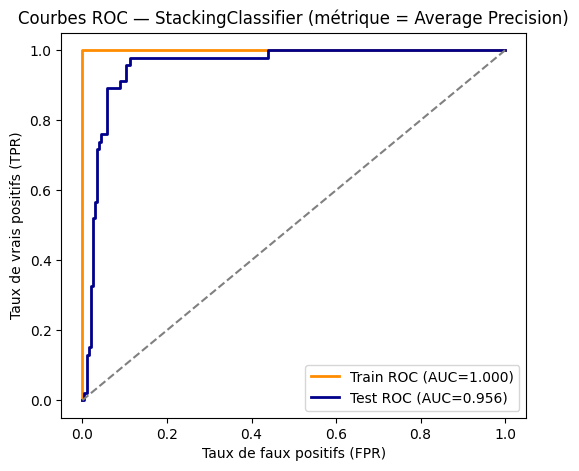

In [35]:
# Courbes ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_proba_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test  = auc(fpr_test,  tpr_test)

plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2,
         label=f'Train ROC (AUC={roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkblue', lw=2,
         label=f'Test ROC (AUC={roc_auc_test:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC — StackingClassifier (métrique = Average Precision)')
plt.legend(loc="lower right")
plt.show()

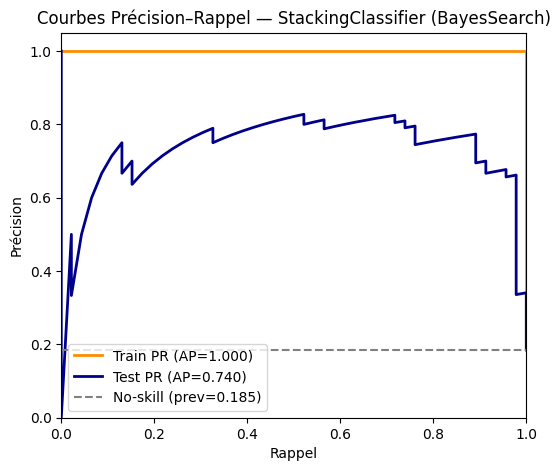

In [36]:
# Courbes Précision–Rappel
prec_train_curve, rec_train_curve, _ = precision_recall_curve(y_train, y_proba_train)
prec_test_curve,  rec_test_curve,  _ = precision_recall_curve(y_test,  y_proba_test)
base_test = y_test.mean()

plt.figure(figsize=(6,5))
plt.plot(rec_train_curve, prec_train_curve, color='darkorange', lw=2,
         label=f'Train PR (AP={ap_train:.3f})')
plt.plot(rec_test_curve, prec_test_curve, color='darkblue', lw=2,
         label=f'Test PR (AP={ap_test:.3f})')
plt.hlines(base_test, 0, 1, colors='gray', linestyles='--',
           label=f'No-skill (prev={base_test:.3f})')
plt.xlabel('Rappel')
plt.ylabel('Précision')
plt.title('Courbes Précision–Rappel — StackingClassifier (BayesSearch)')
plt.legend(loc='lower left')
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.show()

### Importance modele des modeles de base


 IMPORTANCE RELATIVE DES MODÈLES DE BASE
Base_model  Coefficient
       XGB     4.446305
        RF     0.577162
      Tree    -1.352897


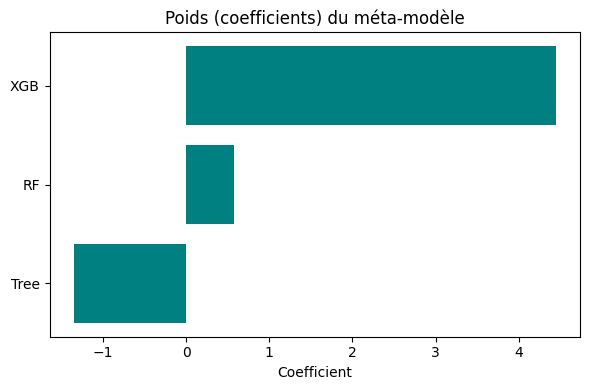

In [37]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Importance relative des modèles de base

# On récupère les sorties du modèle final pour savoir qui "pèse le plus"
meta_model = stack_clf.final_estimator_

# Si le métamodèle est une régression logistique :
if hasattr(meta_model, "coef_"):
    importance_df = pd.DataFrame({
        "Base_model": [name for name, _ in estimators],
        "Coefficient": meta_model.coef_[0]
    }).sort_values("Coefficient", ascending=False)

    print("\n IMPORTANCE RELATIVE DES MODÈLES DE BASE")
    print(importance_df.to_string(index=False))

    plt.figure(figsize=(6,4))
    plt.barh(importance_df["Base_model"][::-1],
             importance_df["Coefficient"][::-1],
             color="teal")
    plt.title("Poids (coefficients) du méta-modèle")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

# Si le métamodèle est un arbre :
elif hasattr(meta_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Base_model": [name for name, _ in estimators],
        "Importance": meta_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("\nIMPORTANCE RELATIVE DES MODÈLES DE BASE")
    print(importance_df.to_string(index=False))

    plt.figure(figsize=(6,4))
    plt.barh(importance_df["Base_model"][::-1],
             importance_df["Importance"][::-1],
             color="darkorange")
    plt.title("Importance relative des modèles de base (arbre)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

### Correlation de prediction entre les modeles


CORRÉLATION ENTRE LES MODÈLES DE BASE
         RF    XGB   Tree
RF    1.000  0.978  0.832
XGB   0.978  1.000  0.831
Tree  0.832  0.831  1.000


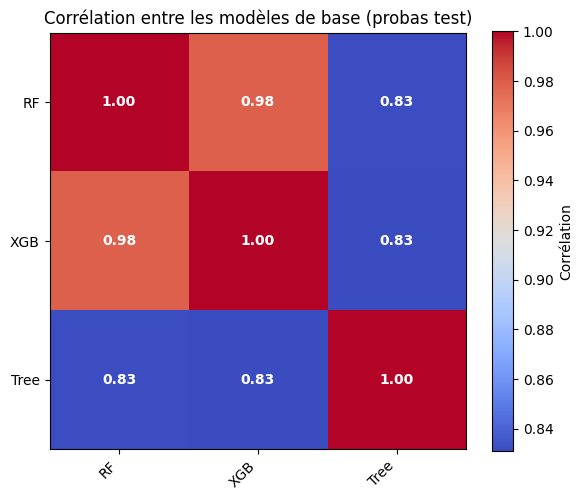

In [38]:
# Corrélations entre les modèles de base

# On calcule les prédictions de probabilité de chaque modèle sur le même jeu
base_preds = pd.DataFrame({
    name: model.predict_proba(X_test)[:, 1]
    for name, model in estimators
})

# Matrice de corrélation
corr = base_preds.corr()

print("\nCORRÉLATION ENTRE LES MODÈLES DE BASE")
print(corr.round(3))

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar(im, label='Corrélation')

# Ajout des valeurs sur la heatmap
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center',
                 color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white',
                 fontsize=10, fontweight='bold')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Corrélation entre les modèles de base (probas test)")
plt.tight_layout()
plt.show()

### Courbe de calibration

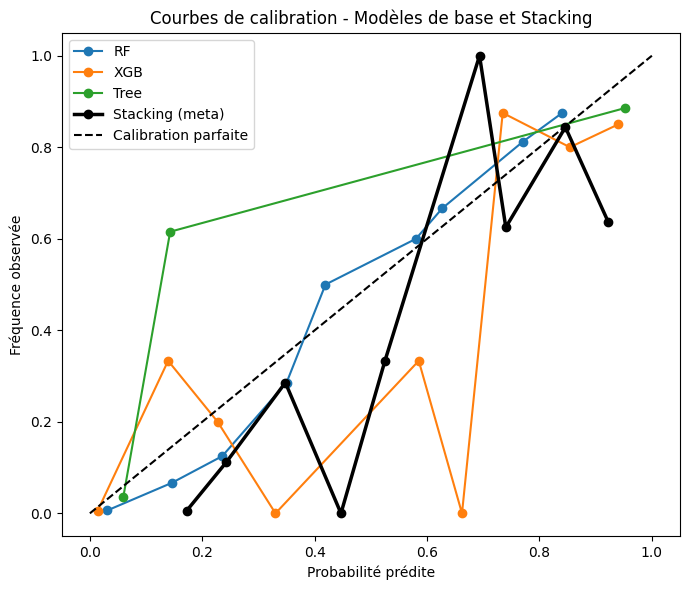

In [39]:
# Courbes de calibration

plt.figure(figsize=(7,6))
for name, model in estimators:
    probas = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, probas, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

# Calibration du stacking
stack_proba = stack_clf.predict_proba(X_test)[:, 1]
frac_pos_stack, mean_pred_stack = calibration_curve(y_test, stack_proba, n_bins=10)
plt.plot(mean_pred_stack, frac_pos_stack, marker='o', color='black', label='Stacking (meta)', linewidth=2.5)

# Ligne parfaite
plt.plot([0,1], [0,1], 'k--', label='Calibration parfaite')

plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence observée")
plt.title("Courbes de calibration - Modèles de base et Stacking")
plt.legend()
plt.tight_layout()
plt.show()

## Comparaison de tous les modeles

### Courbe ROC et Precision-Rappel

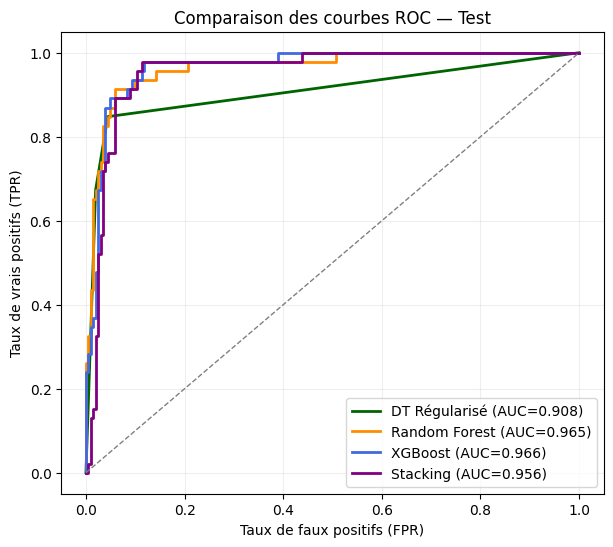

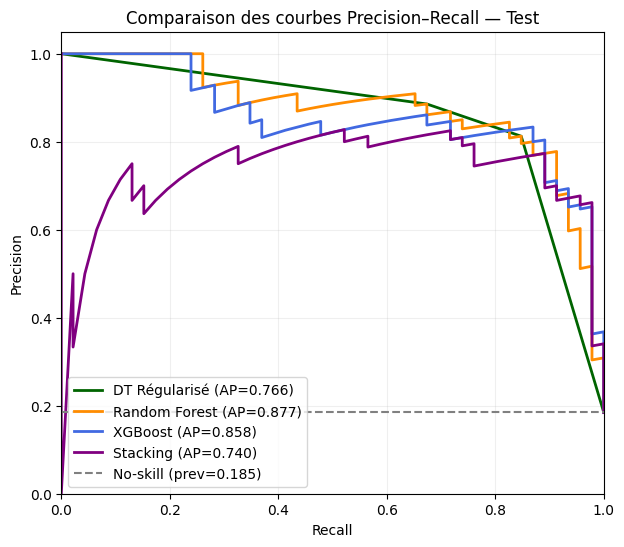

In [40]:
# COURBE ROC — COMPARAISON DES 4 MODÈLES

models = {
    "DT Régularisé": (DT_Reg, 'darkgreen'),
    "Random Forest": (rf_final, 'darkorange'),
    "XGBoost": (xgb_clf, 'royalblue'),
    "Stacking": (stack_clf, 'purple')
}

plt.figure(figsize=(7,6))
for name, (model, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Comparaison des courbes ROC — Test")
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.show()


# COURBE PRECISION / RAPPEL — COMPARAISON

plt.figure(figsize=(7,6))
for name, (model, color) in models.items():
    precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    ap = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(recall, precision, lw=2, color=color, label=f"{name} (AP={ap:.3f})")

plt.hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'No-skill (prev={y_test.mean():.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Comparaison des courbes Precision–Recall — Test")
plt.legend(loc='lower left')
plt.grid(alpha=0.2)
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.show()

### Evaluation sur Test

In [41]:
# TABLEAU SYNTHÉTIQUE COMPARATIF — TEST

models = {
    "DT Régularisé": DT_Reg,
    "Random Forest": rf_final,
    "XGBoost": xgb_clf,
    "Stacking": stack_clf
}

summary_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    summary_data.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC (AP)": average_precision_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

summary = pd.DataFrame(summary_data)
summary = summary.round(3).sort_values(by="PR-AUC (AP)", ascending=False).reset_index(drop=True)

print("\nCOMPARAISON DES MODÈLES (JEU DE TEST)")
display(summary)


COMPARAISON DES MODÈLES (JEU DE TEST)


,Modèle,Accuracy,ROC-AUC,PR-AUC (AP),Precision,Recall,F1-score
0,Random Forest,0.936,0.965,0.877,0.812,0.848,0.830
1,XGBoost,0.932,0.966,0.858,0.774,0.891,0.828
2,DT Régularisé,0.924,0.908,0.766,0.886,0.674,0.765
3,Stacking,0.924,0.956,0.740,0.745,0.891,0.812


## Optimisation de seuil

OPTIMISATION DU SEUIL — STACKING CLASSIFIER
Meilleur seuil : 0.538
F1-score max   : 0.828
Precision      : 0.774
Recall         : 0.891


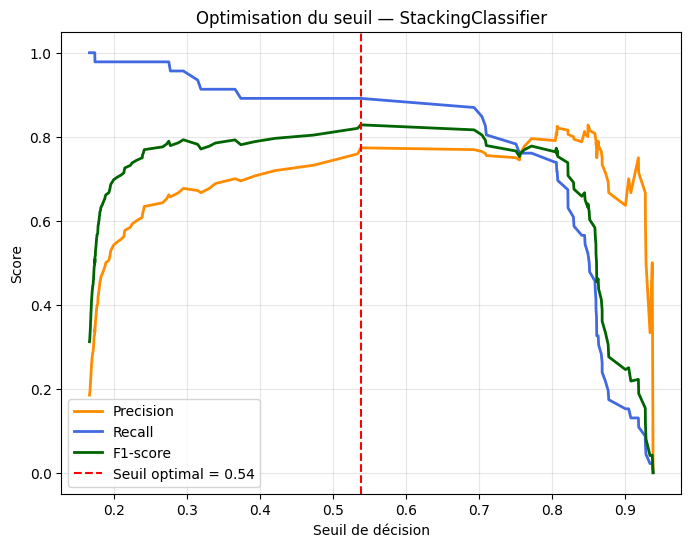


 ÉVALUATION DU STACKING AVEC SEUIL OPTIMAL
Accuracy   : 0.932
Precision  : 0.774
Recall     : 0.891
F1-score   : 0.828

Matrice de confusion :
 [[191  12]
 [  5  41]]

Classification report :
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       203
           1       0.77      0.89      0.83        46

    accuracy                           0.93       249
   macro avg       0.87      0.92      0.89       249
weighted avg       0.94      0.93      0.93       249



In [42]:
# OPTIMISATION DU SEUIL POUR LE STACKING

# Probabilités prédites sur le jeu de test
y_proba_test = stack_clf.predict_proba(X_test)[:, 1]

# Calcul des courbes Precision-Recall pour extraire les seuils
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# Calcul du F1-score pour chaque seuil
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Index du meilleur seuil
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]

print("OPTIMISATION DU SEUIL — STACKING CLASSIFIER")
print(f"Meilleur seuil : {best_threshold:.3f}")
print(f"F1-score max   : {best_f1:.3f}")
print(f"Precision      : {best_precision:.3f}")
print(f"Recall         : {best_recall:.3f}")

# VISUALISATION : PRECISION / RECALL / F1

plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='darkorange', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='royalblue', lw=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-score', color='darkgreen', lw=2)

plt.axvline(best_threshold, color='red', linestyle='--', lw=1.5,
            label=f'Seuil optimal = {best_threshold:.2f}')
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Optimisation du seuil — StackingClassifier")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# ÉVALUATION DU MODÈLE AVEC LE SEUIL OPTIMAL

y_pred_opt = (y_proba_test >= best_threshold).astype(int)

acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print("\n ÉVALUATION DU STACKING AVEC SEUIL OPTIMAL")
print(f"Accuracy   : {acc_opt:.3f}")
print(f"Precision  : {prec_opt:.3f}")
print(f"Recall     : {rec_opt:.3f}")
print(f"F1-score   : {f1_opt:.3f}")
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred_opt))
print("\nClassification report :\n", classification_report(y_test, y_pred_opt))